In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

digits = load_digits()

X = digits.data
y = digits.target

print("数据形状：", X.shape)
print("标签形状：", y.shape)
print("类别：", np.unique(y))

数据形状： (1797, 64)
标签形状： (1797,)
类别： [0 1 2 3 4 5 6 7 8 9]


可视化

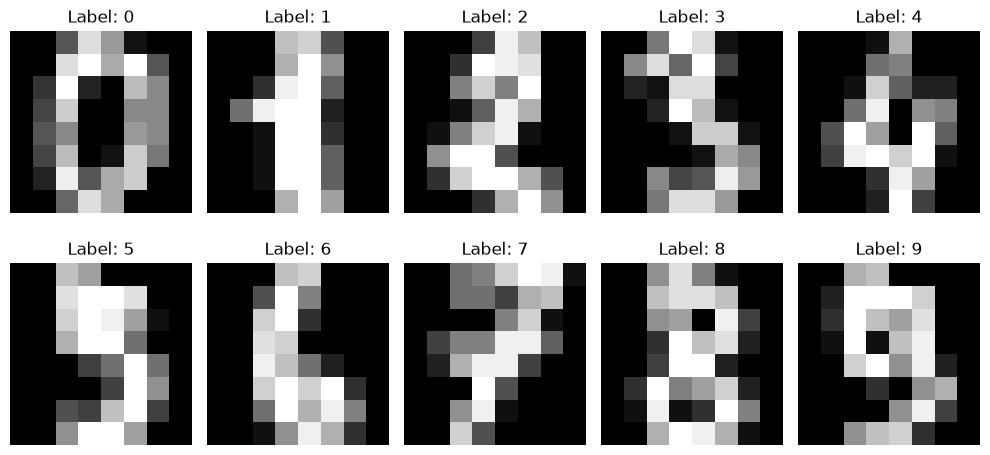

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

划分训练集

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("训练集：", X_train.shape)
print("测试集：", X_test.shape)

训练集： (1437, 64)
测试集： (360, 64)


训练knn

In [4]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("KNN Accuracy =", accuracy)

KNN Accuracy = 0.9861111111111112


bayes

In [5]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print(y_pred_nb[:10])

from sklearn.metrics import accuracy_score

acc_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy =", acc_nb)
proba = nb.predict_proba(X_test[:1])

print(proba)

[5 2 8 8 7 8 6 2 6 7]
Naive Bayes Accuracy = 0.8111111111111111
[[1.40332618e-132 2.22985166e-052 3.53173497e-131 3.70530361e-041
  1.53773182e-050 9.99999928e-001 0.00000000e+000 0.00000000e+000
  1.83621710e-067 7.23064146e-008]]


bayes可视化

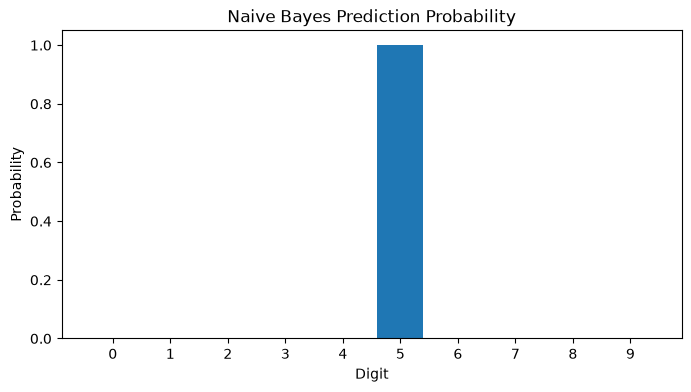

In [6]:
plt.figure(figsize=(8, 4))

plt.bar(range(10), proba[0])

plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.title("Naive Bayes Prediction Probability")

plt.show()

分类

In [8]:
acc_knn = accuracy_score(y_test, y_pred)
acc_nb = accuracy_score(y_test, y_pred_nb)

print("KNN Accuracy:", acc_knn)
print("Naive Bayes Accuracy:", acc_nb)

KNN Accuracy: 0.9861111111111112
Naive Bayes Accuracy: 0.8111111111111111


knn bayes作图

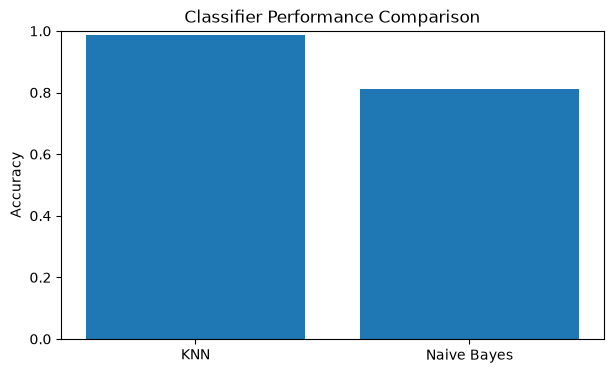

In [9]:
models = ["KNN", "Naive Bayes"]
scores = [acc_knn, acc_nb]

plt.figure(figsize=(7, 4))

plt.bar(models, scores)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Classifier Performance Comparison")

plt.show()

LR

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        random_state=42
    )
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("预测结果：", y_pred_lr[:10])
print("真实标签：", y_test[:10])

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy =", acc_lr)

预测结果： [5 2 8 8 7 2 6 2 6 5]
真实标签： [5 2 8 1 7 2 6 2 6 5]
Logistic Regression Accuracy = 0.9722222222222222


建立比照表

In [11]:
import pandas as pd

results = pd.DataFrame({
    "Classifier": [
        "KNN",
        "Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        acc_knn,
        acc_nb,
        acc_lr
    ]
})

print(results)

            Classifier  Accuracy
0                  KNN  0.986111
1          Naive Bayes  0.811111
2  Logistic Regression  0.972222


作图

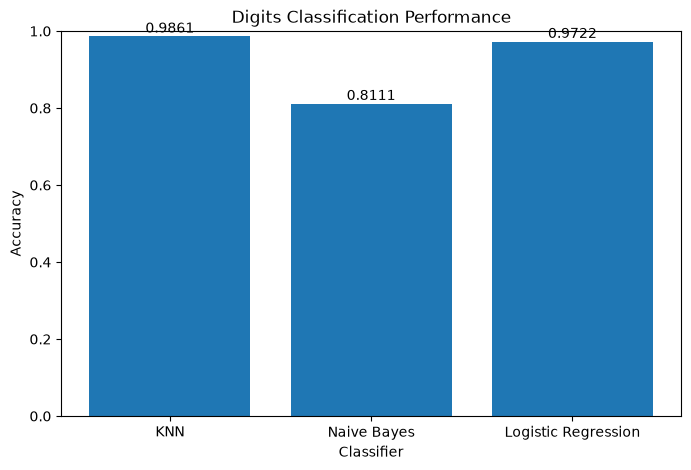

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Classifier"],
    results["Accuracy"]
)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Classifier")
plt.title("Digits Classification Performance")

for i, acc in enumerate(results["Accuracy"]):
    plt.text(
        i,
        acc + 0.01,
        f"{acc:.4f}",
        ha="center"
    )

plt.show()